# 1. Introduction

This notebook builds a simple unsupervised anomaly-detection baseline for weather data using all rows (no train/validation/test split).

Goal:
- Prepare features from meteorology data
- Compare anomaly models on full-dataset behavior
- Inspect top anomalies and interpret results

# 2. Load dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

DATA_PATH = "../data/meteorology_dataset.csv"

df = pd.read_csv(DATA_PATH)
df.columns = [c.strip().lower() for c in df.columns]

if "time" in df.columns:
    df["time"] = pd.to_datetime(df["time"], errors="coerce")

print(f"Rows: {len(df):,} | Columns: {df.shape[1]}")
display(df.head())

Rows: 158,112 | Columns: 17


,location,time,temperature_2m,relative_humidity_2m,dew_point_2m,rain,cloud_cover,cloud_cover_low,cloud_cover_mid,cloud_cover_highh,wind_speed_10m,wind_direction_10m,wind_gusts_10m,wind_direction_100m,wind_speed_100m,pressure_msl,surface_pressure
0,Aveiro,2025-03-05 00:00:00,11.6,79,8.1,0.0,31,0,31,0,4.5,92,9.0,99,15.7,1013.9,1012.8
1,Aveiro,2025-03-05 01:00:00,11.2,90,9.6,0.0,87,9,85,45,18.6,160,29.5,160,27.6,1014.8,1013.7
2,Aveiro,2025-03-05 02:00:00,11.1,90,9.6,0.0,93,0,93,43,5.2,61,30.6,77,13.9,1014.0,1012.9
3,Aveiro,2025-03-05 03:00:00,10.4,94,9.4,0.0,89,0,89,0,6.0,106,9.7,98,13.6,1013.6,1012.5
4,Aveiro,2025-03-05 04:00:00,9.9,95,9.1,0.0,23,0,23,0,6.2,80,10.4,81,14.9,1013.2,1012.1


# 3. Feature selection

In [34]:
candidate_features = [
    "temperature_2m",
    "relative_humidity_2m",
    "dew_point_2m",
    "rain",
    "cloud_cover",
    "wind_speed_10m",
    "pressure_msl",
]

feature_cols = [c for c in candidate_features if c in df.columns]
missing_features = [c for c in candidate_features if c not in df.columns]

if len(feature_cols) == 0:
    raise ValueError("No expected feature columns were found in the dataset.")

X = df[feature_cols].apply(pd.to_numeric, errors="coerce")
X = X.fillna(X.median(numeric_only=True))

print("Selected features:", feature_cols)
if missing_features:
    print("Missing expected features:", missing_features)

Selected features: ['temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'rain', 'cloud_cover', 'wind_speed_10m', 'pressure_msl']


# 4. Data ordering (no split)

In [35]:
# Sort by time to preserve temporal order; all data is used for training (no split).
if "time" in df.columns and df["time"].notna().any():
    all_idx = np.argsort(df["time"].values)
else:
    all_idx = np.arange(len(df))

X_all_raw = X.iloc[all_idx].copy()

print(f"Total samples: {len(X_all_raw)}")

Total samples: 158112


# 5. Feature scaling

In [36]:
scaler = StandardScaler()

X_all_scaled = scaler.fit_transform(X_all_raw)

print("Scaling complete.")

Scaling complete.


# 6. PCA visualization

,pca_1,pca_2
0,-0.161204,-0.995226
1,-1.182867,-0.270586
2,-0.112770,-1.044220
3,-0.299513,-0.739488
4,0.043469,-1.102983


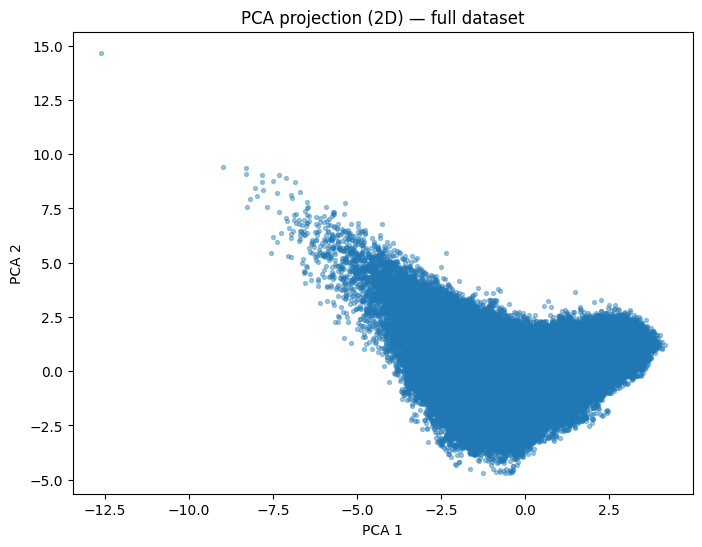

In [37]:
pca = PCA(n_components=2, random_state=42)
X_all_pca = pca.fit_transform(X_all_scaled)

pca_df = pd.DataFrame(X_all_pca, columns=["pca_1", "pca_2"])

display(pca_df.head())

plt.figure(figsize=(8, 6))
plt.scatter(pca_df["pca_1"], pca_df["pca_2"], s=8, alpha=0.4, c="tab:blue")
plt.title("PCA projection (2D) — full dataset")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

# 7. Model testing blocks

In [38]:
def anomaly_percentage(pred):
    return float((pred == -1).mean() * 100)


def fit_predict_all(model, X_all):
    model.fit(X_all)
    pred = model.predict(X_all)
    return {
        "pred": pred,
        "anomaly_pct": anomaly_percentage(pred),
    }

# 8. Train anomaly detection models

In [39]:
models = {
    "IsolationForest": IsolationForest(n_estimators=300, contamination=0.04, random_state=42),
    "LocalOutlierFactor": LocalOutlierFactor(n_neighbors=35, contamination=0.04, novelty=True),
    "OneClassSVM": OneClassSVM(nu=0.04, kernel="rbf", gamma="scale"),
}

model_outputs = {}
rows = []

for model_name, model in models.items():
    out = fit_predict_all(model, X_all_scaled)
    model_outputs[model_name] = out
    rows.append(
        {
            "model": model_name,
            "anomaly_pct": out["anomaly_pct"],
            "n_anomalies": int((out["pred"] == -1).sum()),
        }
    )

comparison_df = pd.DataFrame(rows).sort_values("anomaly_pct")
display(comparison_df)

for _, r in comparison_df.iterrows():
    print(f"{r['model']} -> Anomaly rate: {r['anomaly_pct']:.2f}% ({int(r['n_anomalies'])} samples)")

,model,anomaly_pct,n_anomalies
1,LocalOutlierFactor,3.661961,5790
2,OneClassSVM,3.996534,6319
0,IsolationForest,4.000329,6325


LocalOutlierFactor -> Anomaly rate: 3.66% (5790 samples)
OneClassSVM -> Anomaly rate: 4.00% (6319 samples)
IsolationForest -> Anomaly rate: 4.00% (6325 samples)


# 9. Model selection summary

In [40]:
best_model_name = comparison_df.iloc[0]["model"]
best_model = models[best_model_name]

print(f"Selected by lowest anomaly rate: {best_model_name}")
display(comparison_df[["model", "anomaly_pct"]])

Selected by lowest anomaly rate: LocalOutlierFactor


,model,anomaly_pct
1,LocalOutlierFactor,3.661961
2,OneClassSVM,3.996534
0,IsolationForest,4.000329


# 10. Full-dataset anomaly evaluation

In [41]:
best_pred = model_outputs[best_model_name]["pred"]

if hasattr(best_model, "score_samples"):
    scores = -best_model.score_samples(X_all_scaled)
elif hasattr(best_model, "decision_function"):
    scores = -best_model.decision_function(X_all_scaled)
else:
    scores = np.where(best_pred == -1, 1.0, 0.0)

eval_df = df.iloc[all_idx].copy()
eval_df["anomaly_score"] = scores
eval_df["is_anomaly_raw"] = (best_pred == -1).astype(int)

# Minimal snow-aware filter: keep anomalies only when weather looks snow-compatible.
snow_like_mask = pd.Series(True, index=eval_df.index)
if "temperature_2m" in eval_df.columns:
    snow_like_mask &= eval_df["temperature_2m"] <= 3
if "relative_humidity_2m" in eval_df.columns:
    snow_like_mask &= eval_df["relative_humidity_2m"] >= 75
if "rain" in eval_df.columns:
    snow_like_mask &= eval_df["rain"] >= 0.1

eval_df["is_anomaly"] = (
    (eval_df["is_anomaly_raw"] == 1) & snow_like_mask
).astype(int)

# If the filter is too strict, fall back to raw anomalies.
if eval_df["is_anomaly"].sum() == 0:
    eval_df["is_anomaly"] = eval_df["is_anomaly_raw"]

best_pred_all = np.where(eval_df["is_anomaly"] == 1, -1, 1)

top_anomalies = eval_df[eval_df["is_anomaly"] == 1].sort_values(
    "anomaly_score", ascending=False
).head(20)

print(f"Best model: {best_model_name}")
print(f"Raw anomaly rate: {eval_df['is_anomaly_raw'].mean() * 100:.2f}%")
print(f"Snow-aware anomaly rate: {eval_df['is_anomaly'].mean() * 100:.2f}%")
display(top_anomalies[[c for c in ["time", "location", "temperature_2m", "relative_humidity_2m", "rain", "anomaly_score", "is_anomaly"] if c in top_anomalies.columns]])

Best model: LocalOutlierFactor
Raw anomaly rate: 3.66%
Snow-aware anomaly rate: 0.05%


,time,location,temperature_2m,relative_humidity_2m,rain,anomaly_score,is_anomaly
42151,2025-12-22 07:00:00,Castelo Branco,1.9,99,0.8,2.221725,1
25369,2026-01-24 01:00:00,Braga,1.2,77,1.7,1.914814,1
32658,2025-11-22 18:00:00,Bragança,3.0,84,1.5,1.905418,1
78174,2026-01-28 06:00:00,Guarda,0.3,100,2.4,1.898364,1
25368,2026-01-24 00:00:00,Braga,2.3,84,0.7,1.728666,1
78173,2026-01-28 05:00:00,Guarda,0.5,100,2.7,1.706904,1
78175,2026-01-28 07:00:00,Guarda,1.0,99,1.7,1.675778,1
104023,2026-01-07 07:00:00,Portalegre,2.8,93,0.5,1.664232,1
79055,2026-03-05 23:00:00,Guarda,0.9,100,1.6,1.632917,1
78172,2026-01-28 04:00:00,Guarda,1.0,100,3.2,1.591466,1


# 11. Visualization of anomalies

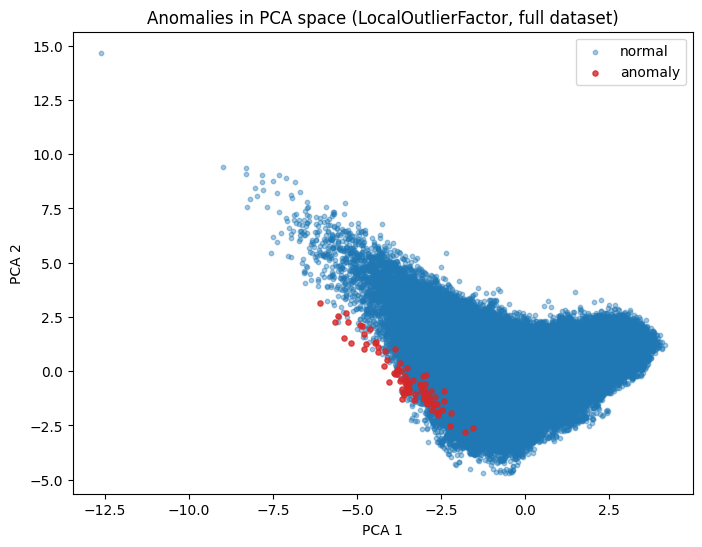

In [42]:
pca_anom_df = pd.DataFrame(X_all_pca, columns=["pca_1", "pca_2"])
pca_anom_df["is_anomaly"] = (best_pred_all == -1)

plt.figure(figsize=(8, 6))
normal = pca_anom_df[~pca_anom_df["is_anomaly"]]
anom = pca_anom_df[pca_anom_df["is_anomaly"]]

plt.scatter(normal["pca_1"], normal["pca_2"], s=10, alpha=0.4, label="normal", c="tab:blue")
plt.scatter(anom["pca_1"], anom["pca_2"], s=14, alpha=0.8, label="anomaly", c="tab:red")

plt.title(f"Anomalies in PCA space ({best_model_name}, full dataset)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.show()

# 12. Interpretation and conclusion (full dataset)

- `pca_1` and `pca_2` are compressed coordinates (not physical weather units).
- Anomaly percentages here are in-sample because models are fit on all data.
- For deeper analysis, inspect top anomalies by time, location, and weather extremes.

Final note:
This notebook is a no-split baseline. You can tune features and model hyperparameters after validating this flow.

# 13. Anomalies vs temperature and rain

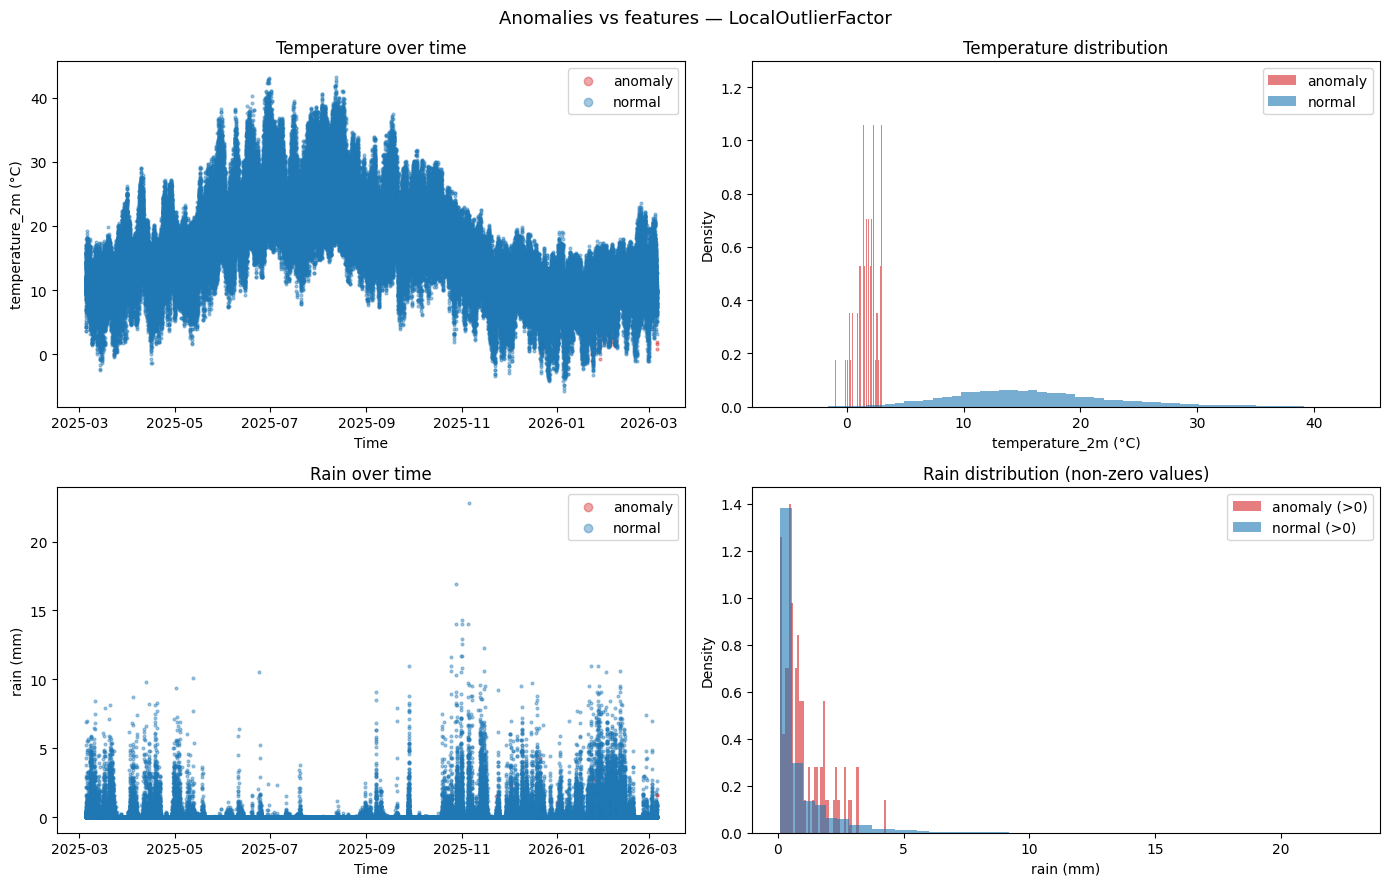

In [43]:
plot_df = eval_df.copy()
plot_df["label"] = plot_df["is_anomaly"].map({1: "anomaly", 0: "normal"})
colors = {"normal": "tab:blue", "anomaly": "tab:red"}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# --- Row 1: temperature ---
if "temperature_2m" in plot_df.columns:
    # Over time
    if "time" in plot_df.columns:
        ax = axes[0, 0]
        for label, grp in plot_df.groupby("label"):
            ax.scatter(grp["time"], grp["temperature_2m"], s=4, alpha=0.4,
                       c=colors[label], label=label)
        ax.set_title("Temperature over time")
        ax.set_xlabel("Time")
        ax.set_ylabel("temperature_2m (°C)")
        ax.legend(markerscale=3)

    # Distribution
    ax = axes[0, 1]
    for label, grp in plot_df.groupby("label"):
        ax.hist(grp["temperature_2m"].dropna(), bins=60, alpha=0.6,
                color=colors[label], label=label, density=True)
    ax.set_title("Temperature distribution")
    ax.set_xlabel("temperature_2m (°C)")
    ax.set_ylabel("Density")
    ax.legend()

# --- Row 2: rain ---
if "rain" in plot_df.columns:
    # Over time
    if "time" in plot_df.columns:
        ax = axes[1, 0]
        for label, grp in plot_df.groupby("label"):
            ax.scatter(grp["time"], grp["rain"], s=4, alpha=0.4,
                       c=colors[label], label=label)
        ax.set_title("Rain over time")
        ax.set_xlabel("Time")
        ax.set_ylabel("rain (mm)")
        ax.legend(markerscale=3)

    # Distribution (log scale to handle heavy zero mass)
    ax = axes[1, 1]
    for label, grp in plot_df.groupby("label"):
        rain_vals = grp["rain"].dropna()
        rain_vals = rain_vals[rain_vals > 0]  # skip zero for log view
        if len(rain_vals):
            ax.hist(rain_vals, bins=50, alpha=0.6, color=colors[label],
                    label=f"{label} (>0)", density=True)
    ax.set_title("Rain distribution (non-zero values)")
    ax.set_xlabel("rain (mm)")
    ax.set_ylabel("Density")
    ax.legend()

plt.suptitle(f"Anomalies vs features — {best_model_name}", fontsize=13)
plt.tight_layout()
plt.show()

# 14. Export dataset with snow_fall label

In [45]:
output_df = df.copy()

# Keep original row order and write the best-model snow flag (0/1).
output_df["snow_fall"] = 0
output_df.loc[eval_df.index, "snow_fall"] = eval_df["is_anomaly"].astype(int)

output_path = "../data/meteorology_dataset_with_snow_fall.csv"
output_df.to_csv(output_path, index=False)

print(f"Saved: {output_path}")
print(f"Best model used: {best_model_name}")
print(f"snow_fall=1 count: {int(output_df['snow_fall'].sum())}")
print(f"snow_fall rate: {output_df['snow_fall'].mean() * 100:.2f}%")
# Print total count of dates with and without snowfall
print(f"Total dates: {len(output_df)}")
print(f"Dates with snowfall: {output_df['snow_fall'].sum()}")
print(f"Dates without snowfall: {len(output_df) - output_df['snow_fall'].sum()}")
display(output_df[[c for c in ["time", "location", "temperature_2m", "rain", "relative_humidity_2m", "snow_fall"] if c in output_df.columns]].head())

Saved: ../data/meteorology_dataset_with_snow_fall.csv
Best model used: LocalOutlierFactor
snow_fall=1 count: 85
snow_fall rate: 0.05%
Total dates: 158112
Dates with snowfall: 85
Dates without snowfall: 158027


,time,location,temperature_2m,rain,relative_humidity_2m,snow_fall
0,2025-03-05 00:00:00,Aveiro,11.6,0.0,79,0
1,2025-03-05 01:00:00,Aveiro,11.2,0.0,90,0
2,2025-03-05 02:00:00,Aveiro,11.1,0.0,90,0
3,2025-03-05 03:00:00,Aveiro,10.4,0.0,94,0
4,2025-03-05 04:00:00,Aveiro,9.9,0.0,95,0
